In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Modelled after damicelli's work. 

import numpy as np
from typing import List, Dict, Optional, Any


from src.ESNs.utils_math import _entropy, _calculate_information_dynamics, _calculate_branching_ratio
import echoes
import numpy as np
from scipy.stats import pearsonr



print(os.getcwd())  # Should show the project root 

# from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS

# from config import COLOR_SCHEME, CATEGORY_COLOURS, CATEGORY_ORDER

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# from src.ESNs.memory_capacity_weighted import evaluate_memory_capacity_from_connectome, evaluate_nonlinear_capacity_from_connectome, evaluate_nonlinear_capacity

In [16]:
# Modelled after damicelli's work. 

import numpy as np
from typing import List, Dict, Optional, Any


from src.ESNs.utils_math import _entropy, _calculate_information_dynamics, _calculate_branching_ratio
import echoes
import numpy as np
from scipy.stats import pearsonr


def alternative_evaluate_mc(W, 
                            h_params):
    """Evaluates the Memory Capacity of a given reservoir matrix W."""
    
    train_len = h_params["train_len"]
    test_len = h_params["test_len"]
    n_lags = h_params["n_lags"]
    
    # 1. Generate data for the MC task
    random_sequence = np.random.uniform(-0.5, 0.5, train_len + test_len)
    X = random_sequence.reshape(-1, 1)
    y = np.zeros((len(X), n_lags))
    for i in range(1, n_lags + 1):
        y[i:, i - 1] = X[:-i, 0]
    
    X_train, X_test = X[:train_len], X[train_len:]
    y_train, y_test = y[:train_len], y[train_len:]

    W = np.array(W, dtype=np.float32)
     
    # 2. Create and train the ESN
    if h_params: 
        esn = echoes.ESNRegressor(
            W=W, 
            spectral_radius=float(h_params["spectral_radius"]), 
            input_scaling=float(h_params["input_scaling"]),  # tends to be string (like "1e-5")
            leak_rate=h_params["leak_rate"], 
            bias=h_params["bias"],
            regression_method=h_params["regression_method"],
            random_state=h_params["random_state"]
        )
    else: 
        Warning("Oh no, no h_params were given to the ESNRegressor in alternative_test_memory_capacity_weighted.py. ")
    
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32)
    y_test = np.array(y_test, dtype=np.float32)
    esn.fit(X_train, y_train)
    
    y_pred = esn.predict(X_test)

    # 3. Calculate the MC score
    mc_score = 0
    r2_scores = []
    for i in range(n_lags):
        # Discard initial transient phase from test data for stable correlation
        corr, _ = pearsonr(y_test[h_params["n_transient"]:, i], y_pred[h_params["n_transient"]:, i]) # Discard initial transient. (statistic, p_value)
        r2_scores.append(corr**2)
        mc_score += corr**2
        
    return mc_score, np.array(r2_scores)





def evaluate_nonlinear_capacity(W, 
                                h_params):
    """Evaluates the quadratic MC = sum of R² for x(t-k)² targets, of a given reservoir matrix W."""
    
    train_len = h_params["train_len"]
    test_len = h_params["test_len"]
    n_lags = h_params["n_lags"]
    
    # 1. Generate data for the MC task
    random_sequence = np.random.uniform(-0.5, 0.5, train_len + test_len)
    X = random_sequence.reshape(-1, 1)
    y = np.zeros((len(X), n_lags))
    for i in range(1, n_lags + 1):
        y[i:, i - 1] = X[:-i, 0]
    
    X_train, X_test = X[:train_len], X[train_len:]
    
    # NEW: Use the quadratic targets for the nonlinear memory capacity evaluation
    y_train, y_test = y[:train_len]**2, y[train_len:]**2
    # y_train, y_test = y[:train_len], y[train_len:]

    W = np.array(W, dtype=np.float32)
     
    # 2. Create and train the ESN
    if h_params: 
        esn = echoes.ESNRegressor(
            W=W, 
            spectral_radius=float(h_params["spectral_radius"]), 
            input_scaling=float(h_params["input_scaling"]),  # tends to be string (like "1e-5")
            leak_rate=h_params["leak_rate"], 
            bias=h_params["bias"],
            regression_method=h_params["regression_method"],
            random_state=h_params["random_state"]
        )
    else: 
        Warning("Oh no, no h_params were given to the ESNRegressor in alternative_test_memory_capacity_weighted.py. ")
    
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32)
    y_test = np.array(y_test, dtype=np.float32)
    esn.fit(X_train, y_train)
    
    y_pred = esn.predict(X_test)

    # 3. Calculate the MC score
    mc_score = 0
    r2_scores = []
    for i in range(n_lags):
        # Discard initial transient phase from test data for stable correlation
        corr, _ = pearsonr(y_test[h_params["n_transient"]:, i], y_pred[h_params["n_transient"]:, i]) # Discard initial transient. (statistic, p_value)
        r2_scores.append(corr**2)
        mc_score += corr**2
        
    return mc_score, np.array(r2_scores)



# This one is the main function to call for evaluating the memory capacity from a connectome. It will call the "alternative_evaluate_mc" function multiple times and then calculate the mean and std of the MC values across runs.
def evaluate_memory_capacity_from_connectome(connectome: np.ndarray, 
                                             h_params: Optional[Dict[str, Any]] = None,
                                             
                                             calculate_criticality:  Optional[bool] = False,
                                             calculate_info_dynamics: Optional[bool] = False,              
 ) -> Dict[str, float]:
    
    mc_values: List[float] = []
    all_states_for_metrics: List[np.ndarray] = []   
    mc_values_indiv_array = []

    # Loop through the number of runs
    for _ in range(h_params["n_runs"]):
        
        (mc_mean, individual_mc_values) = alternative_evaluate_mc(connectome, 
                                                                #   n_lags=n_lags, 
                                                                #   train_len=train_len, 
                                                                #   test_len=test_len,
                                                                  h_params=h_params, 
                                                                  )  
        mc_values.append(mc_mean) # which is only the mean value
        mc_values_indiv_array.append(np.array(individual_mc_values)) # 
        
    # Get the MC for different lags 
    mc_values = np.array(mc_values)
    mc_values_for_indiv_lags = np.mean(np.array(mc_values_indiv_array), axis=0) 
    
    mc_result_dict = {
            "mc_mean": float(np.mean(mc_values)),
            "mc_std": float(np.std(mc_values)), 
            "mc_values_for_indiv_lags": mc_values_for_indiv_lags,
            "h_params": h_params
            }

                                             
                                             
    # TODO: This is not integrated yet - do this later on? -> maybe also in "alternate_evaluate_mc" function?     
    # What about entropy?                           
    if (calculate_criticality or calculate_info_dynamics) and all_states_for_metrics:
        # Concatenate states from all runs for a more robust estimation
        concatenated_states = np.vstack(all_states_for_metrics)
        
        if calculate_criticality:
            branching_ratio = _calculate_branching_ratio(concatenated_states)
            mc_result_dict['branching_ratio'] = branching_ratio
            
        if calculate_info_dynamics:
            info_dyn_results = _calculate_information_dynamics(concatenated_states)
            mc_result_dict.update(info_dyn_results)

    return mc_result_dict
    
    
    
    


# This one is the main function to call for evaluating the memory capacity from a connectome. It will call the "alternative_evaluate_mc" function multiple times and then calculate the mean and std of the MC values across runs.
def evaluate_nonlinear_capacity_from_connectome(connectome: np.ndarray, 
                                             h_params: Optional[Dict[str, Any]] = None,
                                             
                                             calculate_criticality:  Optional[bool] = False,
                                             calculate_info_dynamics: Optional[bool] = False,              
 ) -> Dict[str, float]:
    
    mc_values: List[float] = []
    all_states_for_metrics: List[np.ndarray] = []   
    mc_values_indiv_array = []

    # Loop through the number of runs
    for _ in range(h_params["n_runs"]):
        
        (mc_mean, individual_mc_values) = evaluate_nonlinear_capacity(connectome, 
                                                                #   n_lags=n_lags, 
                                                                #   train_len=train_len, 
                                                                #   test_len=test_len,
                                                                  h_params=h_params, 
                                                                  )  
        mc_values.append(mc_mean) # which is only the mean value
        mc_values_indiv_array.append(np.array(individual_mc_values)) # 
        
    # Get the MC for different lags 
    mc_values = np.array(mc_values)
    mc_values_for_indiv_lags = np.mean(np.array(mc_values_indiv_array), axis=0) 
    
    mc_result_dict = {
            "mc_mean": float(np.mean(mc_values)),
            "mc_std": float(np.std(mc_values)), 
            "mc_values_for_indiv_lags": mc_values_for_indiv_lags,
            "h_params": h_params
            }

    return mc_result_dict
    

In [17]:
A = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_connectomes_density10.npy")[0]
A

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 1, 0]], shape=(100, 100))

In [18]:
# h_params = {
#             "spectral_radius": 0.9,
#             "n_lags": 10, # 50,
#             "train_len": 5000,
#             "test_len": 1000,
#             "n_runs": 50,
#             "input_scaling": 1.0,
#             "regression_method": "pinv",
#             "n_transient": 0, # 100,
#             "leak_rate": 1.0,
#             "bias": 0.0,
#             "random_state": 42
#         }

# results_mc = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

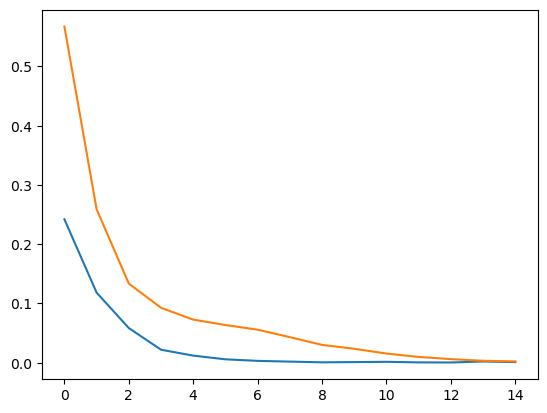

In [ ]:
h_params = {
            "spectral_radius": 0.9, # 0.9
            "n_lags": 15, 
            "train_len": 5000,
            "test_len": 1000,
            "n_runs": 10, # 50,
            "input_scaling": 0.5, # 1.0,
            "regression_method": "ridge", # pinv",
            "n_transient": 100, # 100,
            "leak_rate": 0.3, # 3, #3, # 5, # 1.0,
            "bias": 0.5, # 1.0,
            "random_state": 42
        }

results_nonlin = evaluate_nonlinear_capacity_from_connectome(np.float64(A), h_params=h_params)
results_lin = evaluate_memory_capacity_from_connectome(np.float64(A), h_params=h_params)

plt.plot(results_nonlin["mc_values_for_indiv_lags"], label="Nonlinear Capacity")
plt.plot(results_lin["mc_values_for_indiv_lags"], label="Linear Capacity")

In [ ]:
results_nonlin

{'mc_mean': 0.0542449951171875,
 'mc_std': 0.015362116508185863,
 'mc_values_for_indiv_lags': array([0.00314178, 0.00283335, 0.00146803, 0.00097559, 0.00114335,
        0.00117146, 0.00116838, 0.00115403, 0.00084507, 0.00079513,
        0.00081536, 0.00096983, 0.00088166, 0.00056999, 0.0006887 ,
        0.0011945 , 0.00119349, 0.00100591, 0.00077236, 0.00138083,
        0.00121056, 0.00146586, 0.00105719, 0.00098953, 0.00119289,
        0.00131523, 0.00083947, 0.00077661, 0.00084891, 0.00085594,
        0.00111307, 0.00095234, 0.00112445, 0.00092655, 0.00113163,
        0.00104862, 0.00094519, 0.00115807, 0.00099632, 0.00120157,
        0.0009964 , 0.00105056, 0.00071317, 0.00078861, 0.00087608,
        0.00087692, 0.00094099, 0.00099625, 0.00071653, 0.00097068],
       dtype=float32),
 'h_params': {'spectral_radius': 0.9,
  'n_lags': 50,
  'train_len': 5000,
  'test_len': 1000,
  'n_runs': 50,
  'input_scaling': 1.0,
  'regression_method': 'pinv',
  'n_transient': 0,
  'leak_rate': 1.

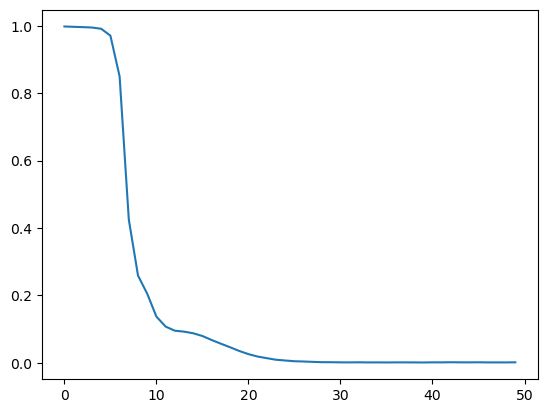

In [ ]:
plt.plot(results_mc["mc_values_for_indiv_lags"], label="Memory Capacity")

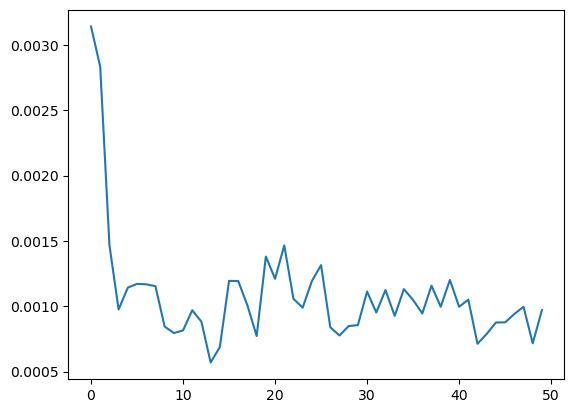

In [ ]:
plt.plot(results_nonlin["mc_values_for_indiv_lags"], label="Nonlinear Capacity")

In [ ]:
# if metric_name == "mc_original": 
#     result = evaluate_memory_capacity_from_connectome(np.float64(self.A), h_params=h_params)
    
# elif metric_name == "mc_nonlinear_original":
#     result = evaluate_nonlinear_capacity_from_connectome(np.float64(self.A), h_params=h_params)


In [23]:
"""
Comprehensive computational capacity assessment of network architectures
via Echo State Network (ESN) reservoir computing.

Measures multiple facets of computation:
  - Linear memory capacity (faithful recall of past inputs)
  - Nonlinear capacity (quadratic/cubic transformations of past inputs)
  - Cross-term capacity (interaction between inputs at different lags)
  - Input separation (discrimination between distinct input streams)
  - State richness (dimensionality and entropy of reservoir dynamics)
  - Edge-of-chaos proximity (Lyapunov exponent estimate)

Compatible with any (N, N) adjacency matrix. Designed for batch evaluation
across tens of thousands of networks.

References:
  - Jaeger (2001) - Echo state networks
  - Büsing et al. (2010) - Connectivity, dynamics, and memory in RC
  - Dambre et al. (2012) - Information processing capacity of dynamical systems
  - Suárez et al. (2024) - Connectome-based reservoir computing (conn2res)
"""

import numpy as np
from scipy import linalg
from typing import Optional


def _prepare_reservoir_weights(
    A: np.ndarray,
    spectral_radius: float = 0.95,
    exc_inh_ratio: float = 0.8,
    rng: np.random.RandomState = None,
) -> np.ndarray:
    """
    Normalize adjacency matrix for ESN use.

    For binary matrices: assigns random excitatory/inhibitory signs (Dale's law)
    to create heterogeneous dynamics. For weighted matrices: preserves relative
    weight structure.

    Always rescales to target spectral_radius.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    W = A.copy().astype(np.float64)
    np.fill_diagonal(W, 0)

    if np.allclose(W, 0):
        return W

    # Check if binary (only 0s and 1s)
    unique_vals = np.unique(W[W > 0])
    is_binary = len(unique_vals) <= 1

    if is_binary:
        # Assign excitatory/inhibitory signs per NODE (Dale's law):
        # each node is either excitatory or inhibitory
        n = W.shape[0]
        n_exc = int(n * exc_inh_ratio)
        signs = np.ones(n)
        inh_nodes = rng.choice(n, size=n - n_exc, replace=False)
        signs[inh_nodes] = -1
        # All outgoing connections from a node have the same sign
        W = W * signs[:, np.newaxis]
    else:
        # Weighted matrix: apply random sign to fraction of edges
        # to introduce inhibitory connections if all weights are positive
        if np.all(W >= 0):
            mask = W > 0
            sign_mask = rng.rand(*W.shape) > exc_inh_ratio
            W[mask & sign_mask] *= -1

    # Normalize spectral radius
    eigenvalues = linalg.eigvals(W)
    rho = np.max(np.abs(eigenvalues))

    if rho < 1e-10:
        return W

    W = W * (spectral_radius / rho)
    return W


def _run_reservoir(
    W: np.ndarray,
    inputs: np.ndarray,
    input_weights: np.ndarray,
    leak_rate: float = 1.0,
    bias: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Drive reservoir with input signal and collect states.

    Parameters
    ----------
    W : (N, N) reservoir weight matrix
    inputs : (T,) or (T, n_inputs) input signal
    input_weights : (N, n_inputs) input-to-reservoir weights
    leak_rate : leaky integration rate (1.0 = no leak = standard ESN)
    bias : (N,) optional bias vector

    Returns
    -------
    states : (T, N) reservoir state matrix
    """
    N = W.shape[0]
    inputs = np.atleast_2d(inputs)
    if inputs.shape[0] == 1:
        inputs = inputs.T  # ensure (T, n_inputs)
    T = inputs.shape[0]

    states = np.zeros((T, N))
    x = np.zeros(N)

    if bias is None:
        bias = np.zeros(N)

    for t in range(T):
        u = input_weights @ inputs[t]
        x_new = np.tanh(W @ x + u + bias)
        x = (1 - leak_rate) * x + leak_rate * x_new
        states[t] = x

    return states


def _ridge_regression(X: np.ndarray, Y: np.ndarray, alpha: float = 1e-4) -> np.ndarray:
    """
    Solve Y = X @ W via ridge regression.
    Returns W of shape (n_features, n_targets).
    """
    # X: (T, n_features), Y: (T, n_targets)
    n = X.shape[1]
    W = linalg.solve(X.T @ X + alpha * np.eye(n), X.T @ Y, assume_a='pos')
    return W


def _r_squared(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination, clipped to [0, 1]."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(np.clip(1 - ss_res / ss_tot, 0.0, 1.0))


def _effective_dimensionality(S: np.ndarray) -> float:
    """
    Effective dimensionality from singular values S.
    Uses the participation ratio: (sum s_i^2)^2 / sum s_i^4
    This equals 1 if one component dominates, N if all equal.
    """
    s2 = S ** 2
    s2 = s2[s2 > 1e-12]
    if len(s2) == 0:
        return 0.0
    return float((np.sum(s2)) ** 2 / np.sum(s2 ** 2))


def _spectral_entropy(S: np.ndarray) -> float:
    """
    Entropy of the normalized singular value spectrum.
    High entropy = rich, distributed dynamics. Low = low-dimensional.
    """
    s2 = S ** 2
    s2 = s2[s2 > 1e-12]
    if len(s2) == 0:
        return 0.0
    p = s2 / np.sum(s2)
    return float(-np.sum(p * np.log(p)))


def computational_capacity(
    A: np.ndarray,
    n_trials: int = 3,
    T_washout: int = 200,
    T_train: int = 2000,
    T_test: int = 500,
    spectral_radius: float = 0.95,
    input_scaling: float = 0.5,
    leak_rate: float = 1.0,
    max_delay: int = 30,
    max_nonlinear_delay: int = 15,
    ridge_alpha: float = 1e-4,
    seed: int = 42,
) -> dict:
    """
    Comprehensive computational capacity assessment of a network.

    Parameters
    ----------
    A : np.ndarray, shape (N, N)
        Adjacency or connectivity matrix. Can be weighted or binary,
        directed or undirected. Will be normalized to desired spectral radius.

    n_trials : int
        Number of independent random input trials to average over.
        More trials = more stable estimates, but slower.

    T_washout : int
        Initial timesteps to discard (let transients decay).

    T_train : int
        Timesteps for training the readout.

    T_test : int
        Timesteps for evaluating capacity (held-out).

    spectral_radius : float
        Target spectral radius for reservoir. 0.9 is standard;
        values near 1.0 probe edge-of-chaos dynamics.

    input_scaling : float
        Scaling of input weights. Small values keep dynamics in
        linear regime of tanh; larger values probe nonlinear regime.

    leak_rate : float
        Leaky integrator rate. 1.0 = standard ESN (no leak).
        Values < 1 slow down dynamics (longer timescales).

    max_delay : int
        Maximum lag for linear memory capacity evaluation.

    max_nonlinear_delay : int
        Maximum lag for nonlinear (quadratic) targets. Kept shorter
        than linear because nonlinear capacity decays faster.

    ridge_alpha : float
        Regularization for ridge regression readout.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    results : dict
        Comprehensive capacity profile with the following keys:

        ## Linear memory capacity
        'memory_capacity_total' : float
            Total linear MC = sum of R² across all lags.
            Theoretical maximum = N (number of nodes).
        'memory_capacity_profile' : np.ndarray, shape (max_delay,)
            R² at each lag k = 1, ..., max_delay.
        'memory_timescale' : float
            Characteristic timescale: lag at which MC drops to 1/e of peak.

        ## Nonlinear computation capacity
        'nonlinear_capacity_total' : float
            Total quadratic MC = sum of R² for x(t-k)² targets.
        'nonlinear_capacity_profile' : np.ndarray, shape (max_nonlinear_delay,)
            R² for each quadratic target.
        'cubic_capacity_total' : float
            Total cubic MC = sum of R² for x(t-k)³ targets.

        ## Cross-term capacity
        'cross_capacity_total' : float
            Total R² for x(t-i)*x(t-j) interaction targets.
            Measures ability to compute conjunctions of past inputs.

        ## Capacity balance
        'memory_nonlinear_ratio' : float
            MC_linear / (MC_linear + MC_nonlinear). Near 1 = memory-dominated
            (routing-like). Near 0 = transformation-dominated (diffusion-like).
        'total_capacity' : float
            Sum of linear + quadratic + cubic + cross capacities.

        ## State richness
        'state_dimensionality' : float
            Participation ratio of reservoir state singular values.
            Higher = richer dynamics exploiting more of the network.
        'state_entropy' : float
            Entropy of normalized singular value spectrum.
        'state_rank' : int
            Numerical rank of the state matrix (singular values > 1e-6).

        ## Input separation
        'separation_ratio' : float
            How well the reservoir separates distinct input streams.
            Measured as ratio of between-class to within-class state variance.

        ## Edge-of-chaos / stability
        'lyapunov_exponent' : float
            Estimated largest Lyapunov exponent from state perturbation.
            Negative = stable (ordered), near 0 = edge of chaos, positive = chaotic.

        ## Summary scores (for quick use in PCA/embedding)
        'capacity_vector' : np.ndarray, shape (8,)
            [memory_total, nonlinear_total, cubic_total, cross_total,
             memory_nonlinear_ratio, state_dimensionality, separation_ratio,
             lyapunov_exponent]
    """
    rng = np.random.RandomState(seed)
    N = A.shape[0]
    T_total = T_washout + T_train + T_test + max_delay

    # Prepare reservoir (signs assigned with rng for reproducibility)
    W = _prepare_reservoir_weights(A, spectral_radius=spectral_radius, rng=rng)

    # Accumulators across trials
    mc_profiles = []
    nl_profiles = []
    cb_profiles = []
    cross_totals = []
    state_dims = []
    state_ents = []
    state_ranks = []
    sep_ratios = []
    lyap_exps = []

    for trial in range(n_trials):
        trial_seed = seed + trial * 1000
        rng_trial = np.random.RandomState(trial_seed)

        # ---- Generate input and drive reservoir ----
        # Uniform input in [-1, 1] (standard for capacity measurement)
        u = rng_trial.uniform(-1, 1, size=T_total)

        # Input weights: all nodes receive input (standard for capacity measurement)
        # Drawn from uniform [-1, 1] and scaled by input_scaling
        w_in = rng_trial.uniform(-1, 1, size=N) * input_scaling
        w_in = w_in.reshape(-1, 1)

        # Small random bias to break symmetry
        bias = rng_trial.uniform(-0.1, 0.1, size=N)

        # Run reservoir
        states = _run_reservoir(W, u.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)

        # Discard washout
        states = states[T_washout:]
        u_valid = u[T_washout:]

        # For predicting u(t-k) from state(t), we need t >= max_delay
        # so all lags 1..max_delay are available as past inputs.
        # States usable for train+test start at index max_delay.
        S_usable = states[max_delay:]  # length = T_train + T_test
        S_train = S_usable[:T_train]
        S_test = S_usable[T_train:T_train + T_test]

        # ---- 1. LINEAR MEMORY CAPACITY ----
        mc_profile = np.zeros(max_delay)
        for k in range(1, max_delay + 1):
            # Target: input k steps before each state
            # S_train[j] = state at absolute time (max_delay + j)
            # target[j] = u_valid[max_delay + j - k]
            y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
            y_train = y_all[:T_train]
            y_test = y_all[T_train:T_train + T_test]

            if len(y_train) < 10 or len(y_test) < 10:
                continue

            W_out = _ridge_regression(S_train, y_train.reshape(-1, 1), alpha=ridge_alpha)
            y_pred = S_test @ W_out
            mc_profile[k - 1] = _r_squared(y_test, y_pred.ravel())

        mc_profiles.append(mc_profile)

        # ---- 2. NONLINEAR (QUADRATIC) CAPACITY ----
        nl_profile = np.zeros(max_nonlinear_delay)
        for k in range(1, max_nonlinear_delay + 1):
            y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
            y_nl = y_all ** 2

            y_train_nl = y_nl[:T_train]
            y_test_nl = y_nl[T_train:T_train + T_test]

            if len(y_train_nl) < 10 or len(y_test_nl) < 10:
                continue

            W_out = _ridge_regression(S_train, y_train_nl.reshape(-1, 1), alpha=ridge_alpha)
            y_pred = S_test @ W_out
            nl_profile[k - 1] = _r_squared(y_test_nl, y_pred.ravel())

        nl_profiles.append(nl_profile)

        # ---- 3. CUBIC CAPACITY ----
        cb_profile = np.zeros(max_nonlinear_delay)
        for k in range(1, max_nonlinear_delay + 1):
            y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
            y_cb = y_all ** 3

            y_train_cb = y_cb[:T_train]
            y_test_cb = y_cb[T_train:T_train + T_test]

            if len(y_train_cb) < 10 or len(y_test_cb) < 10:
                continue

            W_out = _ridge_regression(S_train, y_train_cb.reshape(-1, 1), alpha=ridge_alpha)
            y_pred = S_test @ W_out
            cb_profile[k - 1] = _r_squared(y_test_cb, y_pred.ravel())

        cb_profiles.append(cb_profile)

        # ---- 4. CROSS-TERM CAPACITY ----
        cross_total = 0.0
        n_cross = 0
        for i in range(1, min(8, max_nonlinear_delay)):
            for j in range(i + 1, min(8, max_nonlinear_delay)):
                y_i = u_valid[max_delay - i : max_delay - i + T_train + T_test]
                y_j = u_valid[max_delay - j : max_delay - j + T_train + T_test]
                y_cross = y_i * y_j

                y_train_c = y_cross[:T_train]
                y_test_c = y_cross[T_train:T_train + T_test]

                if len(y_train_c) < 10 or len(y_test_c) < 10:
                    continue

                W_out = _ridge_regression(S_train, y_train_c.reshape(-1, 1), alpha=ridge_alpha)
                y_pred = S_test @ W_out
                cross_total += _r_squared(y_test_c, y_pred.ravel())
                n_cross += 1

        cross_totals.append(cross_total)

        # ---- 5. STATE RICHNESS ----
        # SVD of the full usable states for robust dimensionality estimate
        S_centered = S_usable - S_usable.mean(axis=0)
        try:
            _, S_vals, _ = linalg.svd(S_centered, full_matrices=False)
            state_dims.append(_effective_dimensionality(S_vals))
            state_ents.append(_spectral_entropy(S_vals))
            state_ranks.append(int(np.sum(S_vals > 1e-6 * S_vals[0])))
        except linalg.LinAlgError:
            state_dims.append(0.0)
            state_ents.append(0.0)
            state_ranks.append(0)

        # ---- 6. INPUT SEPARATION ----
        # Drive with two distinct input streams, measure state divergence
        u2 = rng_trial.uniform(-1, 1, size=T_washout + T_test)
        states_alt = _run_reservoir(W, u2.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)
        states_alt = states_alt[T_washout:]

        # Also re-run original input for fair comparison
        u1_seg = u[:T_washout + T_test]
        states_orig = _run_reservoir(W, u1_seg.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)
        states_orig = states_orig[T_washout:]

        min_t = min(len(states_orig), len(states_alt), T_test)
        states_orig = states_orig[:min_t]
        states_alt = states_alt[:min_t]

        # Between-stream distance vs within-stream variance
        between_var = np.mean(np.sum((states_orig - states_alt) ** 2, axis=1))
        within_var = 0.5 * (np.var(states_orig, axis=0).sum() +
                            np.var(states_alt, axis=0).sum())
        if within_var > 1e-12:
            sep_ratios.append(float(between_var / within_var))
        else:
            sep_ratios.append(0.0)

        # ---- 7. LYAPUNOV EXPONENT ESTIMATE ----
        # Perturb initial state slightly, track divergence
        u_lyap = rng_trial.uniform(-1, 1, size=T_washout + 200)

        states_base = _run_reservoir(W, u_lyap.reshape(-1, 1), w_in,
                                     leak_rate=leak_rate, bias=bias)

        # Perturbed run: nudge state at t=T_washout
        eps = 1e-8
        x_base = states_base[T_washout - 1].copy()
        x_pert = x_base + rng_trial.randn(N) * eps

        # Continue both from T_washout with same input
        n_lyap = 200
        divergences = np.zeros(n_lyap)
        x_b = x_base.copy()
        x_p = x_pert.copy()

        for t in range(n_lyap):
            idx = T_washout + t
            if idx >= len(u_lyap):
                break
            inp = w_in.ravel() * u_lyap[idx] + bias
            x_b = (1 - leak_rate) * x_b + leak_rate * np.tanh(W @ x_b + inp)
            x_p = (1 - leak_rate) * x_p + leak_rate * np.tanh(W @ x_p + inp)
            divergences[t] = np.log(np.linalg.norm(x_p - x_b) + 1e-20)

        # Linear fit to log-divergence gives Lyapunov exponent
        valid = np.isfinite(divergences) & (divergences > -40)
        if np.sum(valid) > 10:
            t_vals = np.arange(n_lyap)[valid]
            d_vals = divergences[valid]
            # Simple linear regression
            slope = np.polyfit(t_vals, d_vals, 1)[0]
            lyap_exps.append(float(slope))
        else:
            lyap_exps.append(0.0)

    # ---- AGGREGATE ACROSS TRIALS ----
    mc_profile = np.mean(mc_profiles, axis=0)
    nl_profile = np.mean(nl_profiles, axis=0)
    cb_profile = np.mean(cb_profiles, axis=0)

    mc_total = float(np.sum(mc_profile))
    nl_total = float(np.sum(nl_profile))
    cb_total = float(np.sum(cb_profile))
    cross_total = float(np.mean(cross_totals))

    total_cap = mc_total + nl_total + cb_total + cross_total

    # Memory timescale: find lag where MC drops to 1/e of peak
    if mc_profile.max() > 0:
        threshold = mc_profile.max() / np.e
        below = np.where(mc_profile < threshold)[0]
        memory_timescale = float(below[0] + 1) if len(below) > 0 else float(max_delay)
    else:
        memory_timescale = 0.0

    # Memory vs nonlinear balance
    denom = mc_total + nl_total
    mn_ratio = float(mc_total / denom) if denom > 1e-12 else 0.5

    state_dim = float(np.mean(state_dims))
    state_ent = float(np.mean(state_ents))
    state_rk = int(np.round(np.mean(state_ranks)))
    sep_ratio = float(np.mean(sep_ratios))
    lyap_exp = float(np.mean(lyap_exps))

    # ---- BUILD RESULTS ----
    results = {
        # Linear memory
        'memory_capacity_total': mc_total,
        # 'memory_capacity_profile': mc_profile,
        'memory_timescale': memory_timescale,
        # Nonlinear
        'nonlinear_capacity_total': nl_total,
        # 'nonlinear_capacity_profile': nl_profile,
        'cubic_capacity_total': cb_total,
        # 'cubic_capacity_profile': cb_profile,
        # Cross-terms
        'cross_capacity_total': cross_total,
        # Balance
        'memory_nonlinear_ratio': mn_ratio,
        'total_capacity': total_cap,
        # State richness
        'state_dimensionality': state_dim,
        'state_entropy': state_ent,
        'state_rank': state_rk,
        # Separation
        'separation_ratio': sep_ratio,
        # Stability
        'lyapunov_exponent': lyap_exp,
        # Summary vector for embedding / PCA (8 features)
        # 'capacity_vector': np.array([
        #     mc_total,
        #     nl_total,
        #     cb_total,
        #     cross_total,
        #     mn_ratio,
        #     state_dim,
        #     sep_ratio,
        #     lyap_exp,
        # ]),
    }

    return results


# comp -> computational_capacity

In [24]:
n_trials = 3
T_washout = 200 
T_train = 2000 
T_test = 500 
spectral_radius = 0.95 
input_scaling = 0.5 
leak_rate = 1.0 
max_delay = 30
max_nonlinear_delay = 15
ridge_alpha = 1e-4
seed = 42


rng = np.random.RandomState(seed)
N = A.shape[0]
T_total = T_washout + T_train + T_test + max_delay

# Prepare reservoir (signs assigned with rng for reproducibility)
W = _prepare_reservoir_weights(A, spectral_radius=spectral_radius, rng=rng)

# Accumulators across trials
mc_profiles = []
nl_profiles = []
cb_profiles = []
cross_totals = []
state_dims = []
state_ents = []
state_ranks = []
sep_ratios = []
lyap_exps = []

for trial in range(n_trials):
    trial_seed = seed + trial * 1000
    rng_trial = np.random.RandomState(trial_seed)

    # ---- Generate input and drive reservoir ----
    # Uniform input in [-1, 1] (standard for capacity measurement)
    u = rng_trial.uniform(-1, 1, size=T_total)

    # Input weights: all nodes receive input (standard for capacity measurement)
    # Drawn from uniform [-1, 1] and scaled by input_scaling
    w_in = rng_trial.uniform(-1, 1, size=N) * input_scaling
    w_in = w_in.reshape(-1, 1)

    # Small random bias to break symmetry
    bias = rng_trial.uniform(-0.1, 0.1, size=N)

    # Run reservoir
    states = _run_reservoir(W, u.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)

    # Discard washout
    states = states[T_washout:]
    u_valid = u[T_washout:]

    # For predicting u(t-k) from state(t), we need t >= max_delay
    # so all lags 1..max_delay are available as past inputs.
    # States usable for train+test start at index max_delay.
    S_usable = states[max_delay:]  # length = T_train + T_test
    S_train = S_usable[:T_train]
    S_test = S_usable[T_train:T_train + T_test]

    # ---- 1. LINEAR MEMORY CAPACITY ----
    mc_profile = np.zeros(max_delay)
    for k in range(1, max_delay + 1):
        # Target: input k steps before each state
        # S_train[j] = state at absolute time (max_delay + j)
        # target[j] = u_valid[max_delay + j - k]
        y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
        y_train = y_all[:T_train]
        y_test = y_all[T_train:T_train + T_test]

        if len(y_train) < 10 or len(y_test) < 10:
            continue

        W_out = _ridge_regression(S_train, y_train.reshape(-1, 1), alpha=ridge_alpha)
        y_pred = S_test @ W_out
        mc_profile[k - 1] = _r_squared(y_test, y_pred.ravel())

    mc_profiles.append(mc_profile)

    # ---- 2. NONLINEAR (QUADRATIC) CAPACITY ----
    nl_profile = np.zeros(max_nonlinear_delay)
    for k in range(1, max_nonlinear_delay + 1):
        y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
        y_nl = y_all ** 2

        y_train_nl = y_nl[:T_train]
        y_test_nl = y_nl[T_train:T_train + T_test]

        if len(y_train_nl) < 10 or len(y_test_nl) < 10:
            continue

        W_out = _ridge_regression(S_train, y_train_nl.reshape(-1, 1), alpha=ridge_alpha)
        y_pred = S_test @ W_out
        nl_profile[k - 1] = _r_squared(y_test_nl, y_pred.ravel())

    nl_profiles.append(nl_profile)

    # ---- 3. CUBIC CAPACITY ----
    cb_profile = np.zeros(max_nonlinear_delay)
    for k in range(1, max_nonlinear_delay + 1):
        y_all = u_valid[max_delay - k : max_delay - k + T_train + T_test]
        y_cb = y_all ** 3

        y_train_cb = y_cb[:T_train]
        y_test_cb = y_cb[T_train:T_train + T_test]

        if len(y_train_cb) < 10 or len(y_test_cb) < 10:
            continue

        W_out = _ridge_regression(S_train, y_train_cb.reshape(-1, 1), alpha=ridge_alpha)
        y_pred = S_test @ W_out
        cb_profile[k - 1] = _r_squared(y_test_cb, y_pred.ravel())

    cb_profiles.append(cb_profile)

    # ---- 4. CROSS-TERM CAPACITY ----
    cross_total = 0.0
    n_cross = 0
    for i in range(1, min(8, max_nonlinear_delay)):
        for j in range(i + 1, min(8, max_nonlinear_delay)):
            y_i = u_valid[max_delay - i : max_delay - i + T_train + T_test]
            y_j = u_valid[max_delay - j : max_delay - j + T_train + T_test]
            y_cross = y_i * y_j

            y_train_c = y_cross[:T_train]
            y_test_c = y_cross[T_train:T_train + T_test]

            if len(y_train_c) < 10 or len(y_test_c) < 10:
                continue

            W_out = _ridge_regression(S_train, y_train_c.reshape(-1, 1), alpha=ridge_alpha)
            y_pred = S_test @ W_out
            cross_total += _r_squared(y_test_c, y_pred.ravel())
            n_cross += 1

    cross_totals.append(cross_total)

    # ---- 5. STATE RICHNESS ----
    # SVD of the full usable states for robust dimensionality estimate
    S_centered = S_usable - S_usable.mean(axis=0)
    try:
        _, S_vals, _ = linalg.svd(S_centered, full_matrices=False)
        state_dims.append(_effective_dimensionality(S_vals))
        state_ents.append(_spectral_entropy(S_vals))
        state_ranks.append(int(np.sum(S_vals > 1e-6 * S_vals[0])))
    except linalg.LinAlgError:
        state_dims.append(0.0)
        state_ents.append(0.0)
        state_ranks.append(0)

    # ---- 6. INPUT SEPARATION ----
    # Drive with two distinct input streams, measure state divergence
    u2 = rng_trial.uniform(-1, 1, size=T_washout + T_test)
    states_alt = _run_reservoir(W, u2.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)
    states_alt = states_alt[T_washout:]

    # Also re-run original input for fair comparison
    u1_seg = u[:T_washout + T_test]
    states_orig = _run_reservoir(W, u1_seg.reshape(-1, 1), w_in, leak_rate=leak_rate, bias=bias)
    states_orig = states_orig[T_washout:]

    min_t = min(len(states_orig), len(states_alt), T_test)
    states_orig = states_orig[:min_t]
    states_alt = states_alt[:min_t]

    # Between-stream distance vs within-stream variance
    between_var = np.mean(np.sum((states_orig - states_alt) ** 2, axis=1))
    within_var = 0.5 * (np.var(states_orig, axis=0).sum() +
                        np.var(states_alt, axis=0).sum())
    if within_var > 1e-12:
        sep_ratios.append(float(between_var / within_var))
    else:
        sep_ratios.append(0.0)

    # ---- 7. LYAPUNOV EXPONENT ESTIMATE ----
    # Perturb initial state slightly, track divergence
    u_lyap = rng_trial.uniform(-1, 1, size=T_washout + 200)

    states_base = _run_reservoir(W, u_lyap.reshape(-1, 1), w_in,
                                    leak_rate=leak_rate, bias=bias)

    # Perturbed run: nudge state at t=T_washout
    eps = 1e-8
    x_base = states_base[T_washout - 1].copy()
    x_pert = x_base + rng_trial.randn(N) * eps

    # Continue both from T_washout with same input
    n_lyap = 200
    divergences = np.zeros(n_lyap)
    x_b = x_base.copy()
    x_p = x_pert.copy()

    for t in range(n_lyap):
        idx = T_washout + t
        if idx >= len(u_lyap):
            break
        inp = w_in.ravel() * u_lyap[idx] + bias
        x_b = (1 - leak_rate) * x_b + leak_rate * np.tanh(W @ x_b + inp)
        x_p = (1 - leak_rate) * x_p + leak_rate * np.tanh(W @ x_p + inp)
        divergences[t] = np.log(np.linalg.norm(x_p - x_b) + 1e-20)

    # Linear fit to log-divergence gives Lyapunov exponent
    valid = np.isfinite(divergences) & (divergences > -40)
    if np.sum(valid) > 10:
        t_vals = np.arange(n_lyap)[valid]
        d_vals = divergences[valid]
        # Simple linear regression
        slope = np.polyfit(t_vals, d_vals, 1)[0]
        lyap_exps.append(float(slope))
    else:
        lyap_exps.append(0.0)

# ---- AGGREGATE ACROSS TRIALS ----
mc_profile = np.mean(mc_profiles, axis=0)
nl_profile = np.mean(nl_profiles, axis=0)
cb_profile = np.mean(cb_profiles, axis=0)

mc_total = float(np.sum(mc_profile))
nl_total = float(np.sum(nl_profile))
cb_total = float(np.sum(cb_profile))
cross_total = float(np.mean(cross_totals))

total_cap = mc_total + nl_total + cb_total + cross_total

# Memory timescale: find lag where MC drops to 1/e of peak
if mc_profile.max() > 0:
    threshold = mc_profile.max() / np.e
    below = np.where(mc_profile < threshold)[0]
    memory_timescale = float(below[0] + 1) if len(below) > 0 else float(max_delay)
else:
    memory_timescale = 0.0

# Memory vs nonlinear balance
denom = mc_total + nl_total
mn_ratio = float(mc_total / denom) if denom > 1e-12 else 0.5

state_dim = float(np.mean(state_dims))
state_ent = float(np.mean(state_ents))
state_rk = int(np.round(np.mean(state_ranks)))
sep_ratio = float(np.mean(sep_ratios))
lyap_exp = float(np.mean(lyap_exps))

# ---- BUILD RESULTS ----
results = {
    # Linear memory
    'memory_capacity_total': mc_total,
    # 'memory_capacity_profile': mc_profile,
    'memory_timescale': memory_timescale,
    # Nonlinear
    'nonlinear_capacity_total': nl_total,
    # 'nonlinear_capacity_profile': nl_profile,
    'cubic_capacity_total': cb_total,
    # 'cubic_capacity_profile': cb_profile,
    # Cross-terms
    'cross_capacity_total': cross_total,
    # Balance
    'memory_nonlinear_ratio': mn_ratio,
    'total_capacity': total_cap,
    # State richness
    'state_dimensionality': state_dim,
    'state_entropy': state_ent,
    'state_rank': state_rk,
    # Separation
    'separation_ratio': sep_ratio,
    # Stability
    'lyapunov_exponent': lyap_exp,
    # Summary vector for embedding / PCA (8 features)
    # 'capacity_vector': np.array([
    #     mc_total,
    #     nl_total,
    #     cb_total,
    #     cross_total,
    #     mn_ratio,
    #     state_dim,
    #     sep_ratio,
    #     lyap_exp,
    # ]),
}


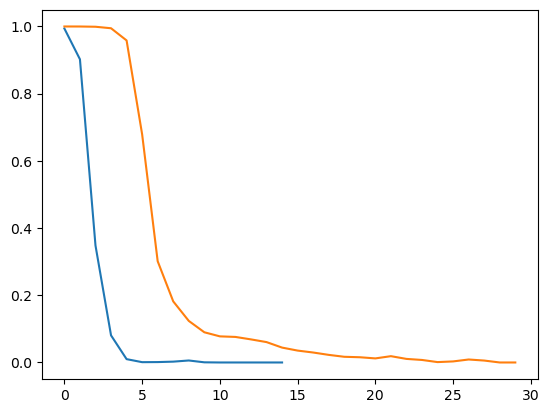

In [ ]:
plt.plot(nl_profile)
plt.plot(mc_profile)


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from src.ipc.utils.information_processing_capacity import single_input_ipc


In [47]:
single_input_ipc

src.ipc.utils.information_processing_capacity.single_input_ipc

In [45]:
##### Parameters for esn #####
N = 50      # Number of nodes
Two = 10000 # Washout time
T = int(1e6)# Time length except washout
p = 0.5     # Sparsity for internal weight
pin = 0.1   # Sparsity for input weight
iota = 0.1  # Input intensity
rhos = 0.1*np.arange(1,13)  # Spectral radius
#Weight
seed = 0
np.random.seed(seed)
win = (2*np.random.rand(N)-1) * (np.random.rand(N)<pin)
w = (2*np.random.rand(N,N)-1) * (np.random.rand(N,N)<p)
eig,eigv = np.linalg.eig(w)
w = w/np.max(np.abs(eig))

##### Input #####
np.random.seed(0)
zeta = 2*np.random.rand(Two+T)-1
print('zeta',zeta,zeta.shape)

# Parameters for IPC
poly = 'legendre'
distr = 'uniform'
degdelays = [[1,2000],[2,300],[3,50],[4,30],[5,15]]
# Class for IPC
ipc = single_input_ipc(zeta,Two,degdelays,poly=poly,distr=distr,zerobased=True)

gpu_id = 0
cp.cuda.Device(gpu_id).use()

# Directory
# pkldir = 'ipc/pkl'

zeta [ 0.09762701  0.43037873  0.20552675 ...  0.61867435 -0.30313547
 -0.51697079] (1010000,)


NameError: name 'np' is not defined

In [43]:
import numpy as np
from scipy import linalg
import ipc  # kubota0130/ipc

def evaluate_ipc_from_connectome(
    A: np.ndarray,
    spectral_radius: float = 0.95,
    input_scaling: float = 0.5,
    leak_rate: float = 1.0,
    T_washout: int = 500,
    T: int = 10_000,        # needs to be long for reliable IPC — kubota recommends ~1e6 ideally
    max_linear_delay: int = 30,
    max_nonlinear_delay: int = 15,
    max_degree: int = 3,
    seed: int = 42,
):
    rng = np.random.RandomState(seed)
    N = A.shape[0]

    # 1. Normalize spectral radius
    W = A.copy().astype(np.float64)
    np.fill_diagonal(W, 0)
    eigvals = linalg.eigvals(W)
    rho = np.max(np.abs(eigvals))
    W = W * (spectral_radius / rho)

    # 2. Generate i.i.d. uniform[-1, 1] input  (required by Legendre basis)
    u = rng.uniform(-1, 1, size=T_washout + T)

    # 3. Random input weights (all nodes receive input)
    w_in = rng.uniform(-1, 1, size=N) * input_scaling
    bias = rng.uniform(-0.1, 0.1, size=N)

    # 4. Run reservoir
    x = np.zeros(N)
    states = np.zeros((T_washout + T, N))
    for t in range(T_washout + T):
        x_new = np.tanh(W @ x + w_in * u[t] + bias)
        x = (1 - leak_rate) * x + leak_rate * x_new
        states[t] = x

    # 5. Discard washout
    states = states[T_washout:]   # (T, N)
    u_valid = u[T_washout:]       # (T,)

    # 6. Build degrees_and_delays for IPC
    #    Tuple format: (degree, delay) where degree=1 → linear, degree=2 → quadratic, etc.
    degrees_and_delays = []
    for deg in range(1, max_degree + 1):
        max_delay = max_linear_delay if deg == 1 else max_nonlinear_delay
        for k in range(1, max_delay + 1):
            degrees_and_delays.append((deg, k))

    # 7. Compute IPC — pass states and input directly
    capacities = computational_capacity(states, u_valid, degrees_and_delays) #  ipc.get_capacity(states, u_valid, degrees_and_delays)

    # 8. Summarise
    results = {
        "linear_mc":      sum(c for (deg, k), c in zip(degrees_and_delays, capacities) if deg == 1),
        "quadratic_mc":   sum(c for (deg, k), c in zip(degrees_and_delays, capacities) if deg == 2),
        "cubic_mc":       sum(c for (deg, k), c in zip(degrees_and_delays, capacities) if deg == 3),
        "total_ipc":      sum(capacities),
        "per_capacity":   list(zip(degrees_and_delays, capacities)),
    }
    return results

In [44]:
evaluate_ipc_from_connectome(A)

TypeError: can only concatenate list (not "int") to list

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from echoes import ESNRegressor

def adjacency_to_mc_profiles(
    A: np.ndarray,
    spectral_radius: float = 0.95,
    input_scaling: float = 0.5,
    leak_rate: float = 0.3,
    n_transient: int = 100,
    train_len: int = 5000,
    test_len: int = 1000,
    max_lag_linear: int = 30,
    max_lag_nonlinear: int = 15,
    n_runs: int = 10,
    random_state: int = 42,
):
    """
    Compute linear and nonlinear (quadratic) memory capacity profiles
    for a given adjacency matrix, using echoes ESNRegressor.

    Parameters
    ----------
    A               : (N, N) adjacency matrix (binary or weighted, any spectral radius)
    spectral_radius : target SR — echoes rescales W internally
    input_scaling   : scales the random input weights inside echoes
    leak_rate       : leaky integrator rate
    n_transient     : warm-up steps discarded from loss (echoes parameter)
    train_len       : training sequence length
    test_len        : test sequence length
    max_lag_linear  : maximum lag k for linear MC  [target: u(t-k)]
    max_lag_nonlinear: maximum lag k for nonlinear MC [target: u(t-k)² - mean]
    n_runs          : number of independent random input draws to average over
    random_state    : base random seed

    Returns
    -------
    mc_linear    : (max_lag_linear,)    mean R² per lag
    mc_nonlinear : (max_lag_nonlinear,) mean R² per lag
    mc_total     : scalar, sum of linear profile
    nl_total     : scalar, sum of nonlinear profile
    """
    rng = np.random.RandomState(random_state)
    W = np.array(A, dtype=np.float64)
    np.fill_diagonal(W, 0)

    mc_runs  = np.zeros((n_runs, max_lag_linear))
    nl_runs  = np.zeros((n_runs, max_lag_nonlinear))

    for run in range(n_runs):
        seed = random_state + run * 100
        total_len = train_len + test_len + max_lag_linear # + n_transient  # extra buffer for lagged targets

        # ── 1. Generate i.i.d. uniform[-1, 1] input ──────────────────────────
        u = np.random.RandomState(seed).uniform(-1, 1, size=total_len).reshape(-1, 1)

        # ── 2. Run ESN (echoes handles SR rescaling + input weights internally) 
        esn = ESNRegressor(
            W=W,
            spectral_radius=spectral_radius,
            input_scaling=input_scaling,
            leak_rate=leak_rate,
            n_transient=n_transient,
            regression_method="pinv",
            random_state=seed,
        )

        # We only need the reservoir states — fit on a dummy target to get states
        # echoes stores states in esn.state_ after fit()
        dummy_target = u[n_transient:train_len]   # shape doesn't matter, just needs a fit call
        esn.fit(u[:train_len], dummy_target)
        states_train = esn.state_[n_transient:]   # (train_len - n_transient, N)

        # Get test states by predicting (this drives the reservoir forward)
        _ = esn.predict(u[train_len:train_len + test_len])
        states_test = esn.state_                  # (test_len, N)

        # ── 3. Linear MC: target = u(t - k) ──────────────────────────────────
        for k in range(1, max_lag_linear + 1):
            # Align lagged input with states
            # states_train[j] corresponds to time (n_transient + j)
            # lagged target: u at (n_transient + j - k)
            lag_train = u[n_transient - k : train_len - k, 0]
            lag_test  = u[train_len - k  : train_len + test_len - k, 0]

            # Fit linear readout on training states
            w_out, *_ = np.linalg.lstsq(states_train, lag_train, rcond=None)
            pred_test  = states_test @ w_out

            corr, _ = pearsonr(lag_test, pred_test)
            mc_runs[run, k - 1] = corr ** 2

        # ── 4. Nonlinear MC: target = u(t-k)² (mean-centred) ─────────────────
        for k in range(1, max_lag_nonlinear + 1):
            lag_train_nl = u[n_transient - k : train_len - k, 0] ** 2
            lag_test_nl  = u[train_len - k  : train_len + test_len - k, 0] ** 2

            # Centre targets (removes DC offset → R² == pearsonr²)
            lag_train_nl -= lag_train_nl.mean()
            lag_test_nl  -= lag_test_nl.mean()

            w_out, *_ = np.linalg.lstsq(states_train, lag_train_nl, rcond=None)
            pred_test  = states_test @ w_out

            corr, _ = pearsonr(lag_test_nl, pred_test)
            nl_runs[run, k - 1] = corr ** 2

    mc_linear    = mc_runs.mean(axis=0)
    mc_nonlinear = nl_runs.mean(axis=0)
    mc_total     = float(mc_linear.sum())
    nl_total     = float(mc_nonlinear.sum())

    return mc_linear, mc_nonlinear, mc_total, nl_total


def plot_mc_profiles(mc_linear, mc_nonlinear, mc_total, nl_total):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ── Left: overlay both profiles ───────────────────────────────────────────
    ax = axes[0]
    ax.plot(np.arange(1, len(mc_linear) + 1),    mc_linear,    label=f"Linear MC  (total={mc_total:.2f})",    color="steelblue", lw=2)
    ax.plot(np.arange(1, len(mc_nonlinear) + 1), mc_nonlinear, label=f"Nonlinear MC (total={nl_total:.2f})", color="darkorange", lw=2)
    ax.set_xlabel("Lag k")
    ax.set_ylabel("R²")
    ax.set_title("Memory capacity profiles")
    ax.set_ylim(0, 1.05)
    ax.legend()

    # ── Right: stacked bar summary ────────────────────────────────────────────
    ax = axes[1]
    ax.bar(["Linear MC", "Nonlinear MC"], [mc_total, nl_total],
           color=["steelblue", "darkorange"], width=0.5)
    ax.set_ylabel("Total capacity (sum of R²)")
    ax.set_title("Total capacity")

    plt.tight_layout()
    return fig


# ── Example usage ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # A = np.load("path/to/your/connectome.npy")

    mc_linear, mc_nonlinear, mc_total, nl_total = adjacency_to_mc_profiles(
        A,
        spectral_radius=0.95,
        input_scaling=0.5,
        leak_rate=0.3,
        max_lag_linear=30,
        max_lag_nonlinear=15,
        n_runs=10,
    )

    print(f"Linear MC total:    {mc_total:.4f}")
    print(f"Nonlinear MC total: {nl_total:.4f}")

    fig = plot_mc_profiles(mc_linear, mc_nonlinear, mc_total, nl_total)
    plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [5000, 4900]

In [54]:
spectral_radius=0.95
input_scaling=0.5
leak_rate=0.3
max_lag_linear=30
max_lag_nonlinear=15
n_runs=10

n_transient = 100
train_len = 5000
test_len = 1000
max_lag_linear = 30
max_lag_nonlinear = 15
n_runs = 10
random_state = 42

rng = np.random.RandomState(random_state)
W = np.array(A, dtype=np.float64)
np.fill_diagonal(W, 0)

mc_runs  = np.zeros((n_runs, max_lag_linear))
nl_runs  = np.zeros((n_runs, max_lag_nonlinear))

for run in range(n_runs):
    seed = random_state + run * 100
    total_len = train_len + test_len + max_lag_linear # + n_transient  # extra buffer for lagged targets

    # ── 1. Generate i.i.d. uniform[-1, 1] input ──────────────────────────
    u = np.random.RandomState(seed).uniform(-1, 1, size=total_len).reshape(-1, 1)

    # ── 2. Run ESN (echoes handles SR rescaling + input weights internally) 
    esn = ESNRegressor(
        W=np.array(W, dtype=np.float32),
        spectral_radius=spectral_radius,
        input_scaling=input_scaling,
        leak_rate=leak_rate,
        n_transient=n_transient,
        regression_method="pinv",
        random_state=seed,
    )

    # We only need the reservoir states — fit on a dummy target to get states
    # echoes stores states in esn.state_ after fit()
    dummy_target = u[n_transient:train_len]   # shape doesn't matter, just needs a fit call
    esn.fit(u[:train_len-n_transient], dummy_target)
    
    break
    
    
#     states_train = esn.state_[n_transient:]   # (train_len - n_transient, N)

#     # Get test states by predicting (this drives the reservoir forward)
#     _ = esn.predict(u[train_len:train_len + test_len])
#     states_test = esn.state_                  # (test_len, N)

#     # ── 3. Linear MC: target = u(t - k) ──────────────────────────────────
#     for k in range(1, max_lag_linear + 1):
#         # Align lagged input with states
#         # states_train[j] corresponds to time (n_transient + j)
#         # lagged target: u at (n_transient + j - k)
#         lag_train = u[n_transient - k : train_len - k, 0]
#         lag_test  = u[train_len - k  : train_len + test_len - k, 0]

#         # Fit linear readout on training states
#         w_out, *_ = np.linalg.lstsq(states_train, lag_train, rcond=None)
#         pred_test  = states_test @ w_out

#         corr, _ = pearsonr(lag_test, pred_test)
#         mc_runs[run, k - 1] = corr ** 2

#     # ── 4. Nonlinear MC: target = u(t-k)² (mean-centred) ─────────────────
#     for k in range(1, max_lag_nonlinear + 1):
#         lag_train_nl = u[n_transient - k : train_len - k, 0] ** 2
#         lag_test_nl  = u[train_len - k  : train_len + test_len - k, 0] ** 2

#         # Centre targets (removes DC offset → R² == pearsonr²)
#         lag_train_nl -= lag_train_nl.mean()
#         lag_test_nl  -= lag_test_nl.mean()

#         w_out, *_ = np.linalg.lstsq(states_train, lag_train_nl, rcond=None)
#         pred_test  = states_test @ w_out

#         corr, _ = pearsonr(lag_test_nl, pred_test)
#         nl_runs[run, k - 1] = corr ** 2

# mc_linear    = mc_runs.mean(axis=0)
# mc_nonlinear = nl_runs.mean(axis=0)
# mc_total     = float(mc_linear.sum())
# nl_total     = float(mc_nonlinear.sum())

# # return mc_linear, mc_nonlinear, mc_total, nl_total


# # def plot_mc_profiles(mc_linear, mc_nonlinear, mc_total, nl_total):
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# # ── Left: overlay both profiles ───────────────────────────────────────────
# ax = axes[0]
# ax.plot(np.arange(1, len(mc_linear) + 1),    mc_linear,    label=f"Linear MC  (total={mc_total:.2f})",    color="steelblue", lw=2)
# ax.plot(np.arange(1, len(mc_nonlinear) + 1), mc_nonlinear, label=f"Nonlinear MC (total={nl_total:.2f})", color="darkorange", lw=2)
# ax.set_xlabel("Lag k")
# ax.set_ylabel("R²")
# ax.set_title("Memory capacity profiles")
# ax.set_ylim(0, 1.05)
# ax.legend()

# # ── Right: stacked bar summary ────────────────────────────────────────────
# ax = axes[1]
# ax.bar(["Linear MC", "Nonlinear MC"], [mc_total, nl_total],
#         color=["steelblue", "darkorange"], width=0.5)
# ax.set_ylabel("Total capacity (sum of R²)")
# ax.set_title("Total capacity")

# plt.tight_layout()


# # fig = plot_mc_profiles(mc_linear, mc_nonlinear, mc_total, nl_total)
# plt.show()


In [60]:
esn.fit(u[:train_len-n_transient], dummy_target)

,n_reservoir,100
,W,"array([[0., 1...dtype=float32)"
,spectral_radius,0.95
,W_in,None
,W_fb,None
,sparsity,0
,noise,0
,leak_rate,0.3
,bias,1
,input_scaling,0.5
,input_shift,None


In [62]:
esn.evaluate(u[:train_len-n_transient], dummy_target)

AttributeError: 'ESNRegressor' object has no attribute 'evaluate'